<a href="https://colab.research.google.com/github/Kaunaingul-ai/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Kaunaingul-ai/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

##Research question and decision

This capstone asks whether public-safe page-level search and content signals can be used to identify and rank content pages that are more likely to be declining, so that editors can prioritize which pages should be reviewed or refreshed first.

The project follows the Refresh / Content Opportunity Scoring lane. The decision supported by the analysis is not whether a page must be changed automatically, but which pages deserve human review first when editorial time is limited. The intended output is therefore a ranked, decision-support list rather than a fully automated content decision.



## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

##Data

This capstone uses the public-safe anonymized starter dataset provided with the FlyRank Machine Learning internship repository. The working file contains page-level search and content features and was the same source used in the earlier framing, baseline, and modeling notebooks.

The analysis uses variables including impressions over 90 days, click-through rate (CTR), average search position, content age, days since last update, and word count. The observed label is whether the page's trend_direction is "down", which is used only as the outcome for evaluation and model training, not as an input feature.

The full FlyRank warehouse release was not accessible at the time of this analysis because the gated resource was still marked as pending/preparation. Therefore, this capstone does not claim to use warehouse tables, private client data, domains, URLs, or queries. All analysis is restricted to the anonymized public-safe starter release.

In [17]:
import os
import subprocess
import pandas as pd

REPO_URL = "https://github.com/Kaunaingul-ai/flyrank-ml-internship"
REPO_DIR = "/content/flyrank-ml-internship"

if not os.path.exists(REPO_DIR):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)

os.chdir(REPO_DIR)

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Date/window field available in starter file:", "date" in df.columns)
print("Public-safe anonymized starter data loaded successfully.")
print("\nColumns used in this capstone:")
print([
    "impressions_90d",
    "ctr",
    "avg_position",
    "content_age_days",
    "days_since_last_update",
    "word_count",
    "trend_direction"
])

Rows: 30000
Columns: 44
Date/window field available in starter file: False
Public-safe anonymized starter data loaded successfully.

Columns used in this capstone:
['impressions_90d', 'ctr', 'avg_position', 'content_age_days', 'days_since_last_update', 'word_count', 'trend_direction']


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

##Methodology

The task is framed as a binary prediction and ranking problem. The target is whether a page has an observed trend_direction of "down". The model estimates the probability of decline, and that probability is then used to rank pages for editorial review.

Six public-safe page-level features are used: impressions_90d, ctr, avg_position, content_age_days, days_since_last_update, and word_count. The outcome variable trend_direction is excluded from the feature set to prevent label leakage.

The learned model is a Random Forest classifier. This method was selected because earlier analysis showed that the relationships among search visibility, CTR, content age, staleness, and decline were not strictly linear. Missing numeric values are handled using median imputation.

For validation, the data is split into 80% training and 20% held-out validation data using stratification so that the proportion of declining pages remains similar in both sets. A fixed random seed is used for reproducibility.

The Random Forest is compared against the Week-4 rule-based baseline on the same validation rows. The baseline assigns one point for staleness and one point for low CTR in a moderate search-position range, with impressions used only as a small tie-breaker. The main comparison metric is Precision@50 because the practical decision is which limited set of pages should be reviewed first.

In [18]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

features = [
    "impressions_90d",
    "ctr",
    "avg_position",
    "content_age_days",
    "days_since_last_update",
    "word_count"
]

X = df[features].copy()
y = (df["trend_direction"] == "down").astype(int)

# Honest hold-out split
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Leakage check
forbidden_features = {"trend_direction"}
used_forbidden = forbidden_features.intersection(X.columns)

print("Training rows:", len(X_train))
print("Validation rows:", len(X_valid))
print("Training decline rate:", round(y_train.mean(), 3))
print("Validation decline rate:", round(y_valid.mean(), 3))
print("Forbidden outcome features used:", len(used_forbidden) > 0)

# Week-4 baseline
baseline_valid = X_valid.copy()

baseline_valid["is_stale"] = (
    baseline_valid["days_since_last_update"] >= 90
).astype(int)

baseline_valid["low_ctr_for_position"] = (
    (baseline_valid["avg_position"] >= 4)
    & (baseline_valid["avg_position"] <= 20)
    & (baseline_valid["ctr"] < 0.10)
).astype(int)

baseline_valid["baseline_score"] = (
    baseline_valid["is_stale"]
    + baseline_valid["low_ctr_for_position"]
)

baseline_rank_score = (
    baseline_valid["baseline_score"]
    + baseline_valid["impressions_90d"].rank(pct=True) * 0.001
)

# Random Forest
rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Training rows: 24000
Validation rows: 6000
Training decline rate: 0.542
Validation decline rate: 0.542
Forbidden outcome features used: False
Random Forest trained successfully.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

##Results versus baseline

The Random Forest and the Week-4 rule-based baseline were evaluated on the same 6,000 held-out validation rows using the same primary ranking metric, Precision@50.

The baseline achieved a Precision@50 of 0.60, meaning 30 of its top 50 ranked pages were observed to be declining. The Random Forest achieved a Precision@50 of 0.88, meaning 44 of its top 50 ranked pages were observed to be declining.

The Random Forest therefore produced a substantially stronger top-of-list ranking in this validation sample. Its secondary metrics were an Average Precision of 0.733 and a ROC AUC of 0.723. These results support the use of the model as a ranking aid for editorial review, while not implying causal effects or knowledge of Google's ranking algorithm.

In [19]:
from sklearn.metrics import average_precision_score, roc_auc_score

def precision_at_k(scores, y_true, k=50):
    scores = np.asarray(scores)
    y_true = np.asarray(y_true)

    top_idx = np.argsort(scores)[::-1][:k]
    return y_true[top_idx].mean()

# Random Forest probabilities
rf_score = rf_model.predict_proba(X_valid)[:, 1]

# Same metric for both methods
baseline_p50 = precision_at_k(
    baseline_rank_score,
    y_valid,
    k=50
)

rf_p50 = precision_at_k(
    rf_score,
    y_valid,
    k=50
)

comparison = pd.DataFrame({
    "Method": ["Week-4 baseline", "Random Forest"],
    "Precision@50": [baseline_p50, rf_p50]
})

print("Model vs baseline:")
display(comparison.round(3))

print("Random Forest secondary metrics:")
print("Average Precision:", round(average_precision_score(y_valid, rf_score), 3))
print("ROC AUC:", round(roc_auc_score(y_valid, rf_score), 3))

print("\nTop-50 counts:")
print("Baseline true declining pages:", int(round(baseline_p50 * 50)))
print("Random Forest true declining pages:", int(round(rf_p50 * 50)))

Model vs baseline:


,Method,Precision@50
0,Week-4 baseline,0.60
1,Random Forest,0.88


Random Forest secondary metrics:
Average Precision: 0.733
ROC AUC: 0.723

Top-50 counts:
Baseline true declining pages: 30
Random Forest true declining pages: 44


## 5. Limitations

*What this work cannot claim.*

##Limitations

This analysis has several important limitations. First, it uses the anonymized public-safe starter dataset rather than the full FlyRank warehouse release, because the gated warehouse resource was not available at the time of analysis. As a result, the analysis does not include richer warehouse tables, private query-level information, client context, or explicit calendar date windows.

Second, the validation design uses a stratified random hold-out split because the starter file does not provide a client grouping field or a clear time variable for grouped or time-aware validation. Therefore, the reported metrics should be interpreted as validation performance within this dataset, not as evidence of future performance across clients or time periods.

Third, the model identifies statistical patterns associated with the observed decline label. It does not establish that any feature causes decline, and it does not explain or predict Google’s ranking algorithm.

Finally, the model should be used as a decision-support tool. A high decline score indicates that a page may deserve review, but editorial decisions should still consider context such as seasonality, page purpose, query intent, content quality, and business priorities.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

##Ranked recommendations

The model output is converted into a ranked editorial review queue. Pages with higher predicted decline probability are reviewed first, but the score is used only for prioritization rather than automatic action.

The recommended action is REVIEW_FIRST for the highest-ranked pages. Editors should inspect these pages for possible refresh, rewrite, consolidation, or monitoring based on context. The table below uses only anonymized public-safe identifiers and model features; it does not expose client names, URLs, domains, or private queries.

In [20]:
# Build ranked recommendation queue from validation pages

recommendations = X_valid.copy()
recommendations["content_id"] = df.loc[X_valid.index, "content_id"]
recommendations["actual_decline"] = y_valid
recommendations["decline_score"] = rf_score

recommendations = recommendations.sort_values(
    "decline_score",
    ascending=False
).copy()

recommendations["rank"] = np.arange(1, len(recommendations) + 1)

recommendations["recommended_action"] = np.where(
    recommendations["rank"] <= 50,
    "REVIEW_FIRST",
    "MONITOR"
)

top20_recommendations = recommendations[
    [
        "rank",
        "content_id",
        "decline_score",
        "impressions_90d",
        "ctr",
        "avg_position",
        "content_age_days",
        "days_since_last_update",
        "recommended_action"
    ]
].head(20)

print("Top 20 ranked recommendations:")
display(top20_recommendations)

print("\nTop-50 summary:")
print("Pages marked REVIEW_FIRST:", (recommendations["recommended_action"] == "REVIEW_FIRST").sum())
print(
    "Observed declining pages among top 50:",
    int(recommendations.head(50)["actual_decline"].sum())
)

Top 20 ranked recommendations:


,rank,content_id,decline_score,impressions_90d,ctr,avg_position,content_age_days,days_since_last_update,recommended_action
7882,1,content_25a763874cf0,0.764794,908,0.11,27.4,144,104,REVIEW_FIRST
15921,2,content_f2813e0b8901,0.764164,3375,0.12,30.2,165,104,REVIEW_FIRST
11176,3,content_b7c3994aa0e8,0.764129,1196,0.00,31.1,165,104,REVIEW_FIRST
25857,4,content_ffef3141126f,0.764062,187,0.00,17.6,165,104,REVIEW_FIRST
4164,5,content_cae546aab87e,0.763881,256,0.00,23.2,155,104,REVIEW_FIRST
24397,6,content_7dcd5d29a6f2,0.763504,187,0.00,28.0,165,104,REVIEW_FIRST
3531,7,content_d3b6b4aae679,0.763380,697,0.14,28.1,155,104,REVIEW_FIRST
606,8,content_f192f3938827,0.763306,880,0.00,30.6,165,104,REVIEW_FIRST
16823,9,content_54bda6d2e0dd,0.762937,140,0.00,29.6,165,104,REVIEW_FIRST
25808,10,content_d0e81e632d6f,0.762724,1076,0.09,25.8,144,104,REVIEW_FIRST



Top-50 summary:
Pages marked REVIEW_FIRST: 50
Observed declining pages among top 50: 44


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

##Artifacts for the deployed paper

The deployed research paper will include a small set of public-safe figures and tables generated directly from the capstone analysis. These artifacts summarize the main model comparison, feature importance, and ranked recommendations without exposing private client information, URLs, domains, or queries.

The primary artifacts are:

A model-versus-baseline comparison chart using Precision@50.
A Random Forest feature-importance chart.
A compact table of the highest-ranked public-safe recommendations.

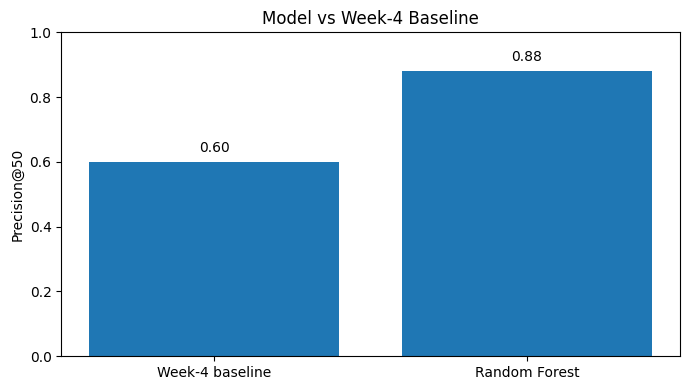

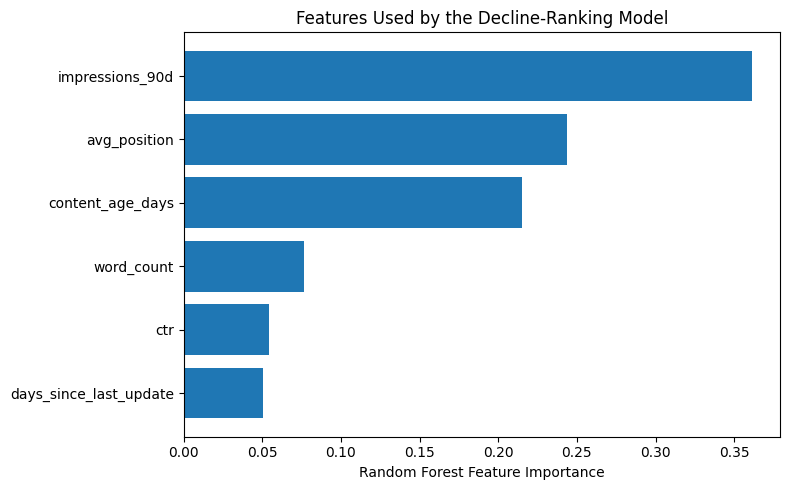

Public-safe Top-10 recommendation table:


,rank,content_id,decline_score,impressions_90d,ctr,avg_position,recommended_action
7882,1,content_25a763874cf0,0.765,908,0.11,27.4,REVIEW_FIRST
15921,2,content_f2813e0b8901,0.764,3375,0.12,30.2,REVIEW_FIRST
11176,3,content_b7c3994aa0e8,0.764,1196,0.00,31.1,REVIEW_FIRST
25857,4,content_ffef3141126f,0.764,187,0.00,17.6,REVIEW_FIRST
4164,5,content_cae546aab87e,0.764,256,0.00,23.2,REVIEW_FIRST
24397,6,content_7dcd5d29a6f2,0.764,187,0.00,28.0,REVIEW_FIRST
3531,7,content_d3b6b4aae679,0.763,697,0.14,28.1,REVIEW_FIRST
606,8,content_f192f3938827,0.763,880,0.00,30.6,REVIEW_FIRST
16823,9,content_54bda6d2e0dd,0.763,140,0.00,29.6,REVIEW_FIRST
25808,10,content_d0e81e632d6f,0.763,1076,0.09,25.8,REVIEW_FIRST


In [21]:
import matplotlib.pyplot as plt

# -----------------------------
# Artifact 1: Model comparison
# -----------------------------
comparison_plot = comparison.copy()

plt.figure(figsize=(7, 4))
plt.bar(
    comparison_plot["Method"],
    comparison_plot["Precision@50"]
)
plt.ylim(0, 1)
plt.ylabel("Precision@50")
plt.title("Model vs Week-4 Baseline")

for i, value in enumerate(comparison_plot["Precision@50"]):
    plt.text(i, value + 0.03, f"{value:.2f}", ha="center")

plt.tight_layout()
plt.show()


# -----------------------------
# Artifact 2: Feature importance
# -----------------------------
rf_estimator = rf_model.named_steps["model"]

importance_table = pd.DataFrame({
    "Feature": features,
    "Importance": rf_estimator.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(
    importance_table["Feature"],
    importance_table["Importance"]
)
plt.xlabel("Random Forest Feature Importance")
plt.title("Features Used by the Decline-Ranking Model")
plt.tight_layout()
plt.show()


# -----------------------------
# Artifact 3: Compact top-10 table
# -----------------------------
paper_top10 = top20_recommendations[
    [
        "rank",
        "content_id",
        "decline_score",
        "impressions_90d",
        "ctr",
        "avg_position",
        "recommended_action"
    ]
].head(10).copy()

paper_top10["decline_score"] = paper_top10["decline_score"].round(3)
paper_top10["ctr"] = paper_top10["ctr"].round(3)
paper_top10["avg_position"] = paper_top10["avg_position"].round(1)

print("Public-safe Top-10 recommendation table:")
display(paper_top10)

#ML-12 — 5-minute demo outline

###1. Problem — 45 seconds
The project addresses a practical editorial question: when review time is limited, which content pages should be examined first for possible decline? The goal is prioritization, not automatic content changes.

###2. Data — 45 seconds
I used the anonymized public-safe FlyRank starter dataset containing 30,000 page-level observations. The analysis used impressions over 90 days, CTR, average search position, content age, days since last update, and word count. The gated full warehouse was not accessible, so no private client data, URLs, domains, or queries were used.

###3. Method — 60 seconds
I framed the task as decline prediction followed by ranking. A Random Forest classifier was trained on 80% of the data and evaluated on a stratified 20% hold-out set. The observed trend_direction == "down" outcome was used as the label but was excluded from model inputs to avoid leakage.

###4. Baseline comparison — 60 seconds
I compared the learned model with the Week-4 rule-based baseline on the same 6,000 validation rows using Precision@50. The baseline achieved 0.60, while the Random Forest achieved 0.88. The model also obtained Average Precision of 0.733 and ROC AUC of 0.723.

###5. Recommendations and limitations — 60 seconds
The model generates a ranked review queue, with the highest-scoring pages marked REVIEW_FIRST. Forty-four of the model's top 50 recommendations were observed declining pages in the held-out sample. These results are decision-support evidence only; they do not establish causality, predict Google's algorithm, or guarantee future performance.

###6. Takeaway — 30 seconds
The project shows how an interpretable baseline can be improved with a machine-learning ranking model while keeping evaluation, leakage controls, public-safety constraints, and human review central to the workflow.

#ML-12 — Social post

I completed a machine-learning capstone focused on content decline prioritization and editorial decision support.

Using an anonymized public-safe dataset of 30,000 content pages, I built and evaluated a Random Forest model for ranking pages that may deserve review. On the same held-out validation set, the model improved Precision@50 from 0.60 for the rule-based baseline to 0.88, with 44 of its top 50 recommendations corresponding to observed declining pages.

The project covered problem framing, leakage-aware feature design, baseline construction, model validation, error analysis, ranked recommendations, and reproducible reporting. The model is designed as a decision-support tool, not an automatic content decision system.

#MachineLearning #DataScience #RandomForest #MLProjects #AI #Internship

#ML-12 — Employer-facing summary

I built an end-to-end machine-learning workflow that ranks content pages for editorial review using anonymized search and content signals. On a 6,000-row held-out validation set, the Random Forest achieved Precision@50 of 0.88, compared with 0.60 for the rule-based baseline, while maintaining explicit leakage controls and public-safe reporting. The project demonstrates practical skills in problem framing, data preparation, model evaluation, ranking, error analysis, reproducibility, and translating model outputs into decision-support recommendations.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
